# Verificações de *long guns* por estado — NICS, novembro de 2015

Extração da tabela do relatório **NICS Firearm Background Checks** (FBI) a partir do PDF
`background-checks.pdf` e reprodução do gráfico de `grafico-long-guns.html`.

O caminho é o mesmo de ponta a ponta:

1. abrir o PDF e pegar as palavras **com suas coordenadas**;
2. usar o cabeçalho para descobrir onde cada uma das 24 colunas começa e termina;
3. agrupar as palavras em linhas pela coordenada vertical e encaixar cada número na coluna mais próxima;
4. **validar** o resultado contra os totais impressos no próprio PDF;
5. desenhar o gráfico de barras da coluna `Long Gun`.

> O PDF não tem uma "tabela" no sentido de estrutura de dados — tem texto posicionado em uma página.
> `extract_table()` do pdfplumber se perde aqui (junta 5 estados numa célula só, porque a tabela não
> tem linhas de grade horizontais). Por isso a extração é feita na mão, pelas coordenadas.

In [1]:
import pathlib
import pdfplumber
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.transforms import blended_transform_factory

PDF = pathlib.Path("background-checks.pdf")
print("pdfplumber", pdfplumber.__version__, "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)
print("arquivo:", PDF.resolve(), f"({PDF.stat().st_size/1024:.1f} KB)")

pdfplumber 0.11.10 | pandas 3.0.5 | matplotlib 3.11.1
arquivo: /Users/dudureale/IbmecPriv/Ibmec/ExtracaoDeDados/Ac3/background-checks.pdf (88.3 KB)


## 1. Abrir o PDF e olhar as palavras

`extract_words()` devolve cada palavra com sua caixa: `x0`/`x1` (esquerda/direita) e `top`
(distância do topo da página). São essas coordenadas — e não a ordem do texto — que reconstroem a tabela.

In [2]:
pdf = pdfplumber.open(PDF)
pagina = pdf.pages[0]
palavras = pagina.extract_words()

print(f"páginas no PDF: {len(pdf.pages)}")
print(f"tamanho da página: {pagina.width:.0f} x {pagina.height:.0f} pt (paisagem)")
print(f"palavras extraídas: {len(palavras)}\n")

pd.DataFrame(palavras)[["text", "x0", "x1", "top"]].head(12).round(1)

páginas no PDF: 1
tamanho da página: 1008 x 612 pt (paisagem)
palavras extraídas: 1499



,text,x0,x1,top
0,NICS,408.1,444.1,26.5
1,Firearm,448.4,500.3,26.5
2,Background,504.7,585.6,26.5
3,Checks,589.9,640.4,26.5
4,November,465.9,536.0,45.0
5,-,540.3,545.3,45.0
6,2015,549.6,583.3,45.0
7,Pre-Pawn,336.6,362.6,64.0
8,Redemption,446.7,480.0,64.0
9,Returned/Disposition,548.0,606.5,64.0


In [3]:
# a linha do Alabama, do jeito que ela existe no PDF: 1 nome + 22 números
linha_alabama = sorted((p for p in palavras if abs(p["top"] - 80.4) < 3), key=lambda p: p["x0"])
print(" ".join(p["text"] for p in linha_alabama))

Alabama 18,870 23,022 22,650 859 1,178 0 14 15 0 2,179 2,307 11 0 0 0 13 14 0 3 2 0 71,137


## 2. O cabeçalho define as colunas

A tabela tem dois níveis de cabeçalho: uma faixa de grupos (`Pre-Pawn`, `Redemption`, `Rentals`, …)
e, abaixo, os rótulos de cada coluna (`Handgun`, `Long Gun`, `*Other`). Pegamos a linha de baixo
(`top ≈ 73`), juntamos os pares `Long` + `Gun` e guardamos o **centro horizontal** de cada coluna.
Depois prefixamos cada coluna com o nome do seu grupo, na quantidade que cada grupo ocupa.

In [4]:
cab = sorted((p for p in palavras if 70 < p["top"] < 76 and p["x0"] > 110), key=lambda p: p["x0"])

colunas = []          # (rótulo curto, centro x)
i = 0
while i < len(cab):
    p = cab[i]
    if p["text"] == "Long" and i + 1 < len(cab) and cab[i + 1]["text"] == "Gun":
        colunas.append(("Long Gun", (p["x0"] + cab[i + 1]["x1"]) / 2))
        i += 2
    else:
        colunas.append((p["text"], (p["x0"] + p["x1"]) / 2))
        i += 1

# quantas colunas cada grupo do cabeçalho de cima ocupa
GRUPOS = [("", 6), ("Pre-Pawn", 3), ("Redemption", 3), ("Returned/Disposition", 3),
          ("Rentals", 2), ("Private Sale", 3), ("Return to Seller - Private Sale", 3), ("", 1)]

nomes, k = [], 0
for grupo, n in GRUPOS:
    for _ in range(n):
        rotulo, _centro = colunas[k]
        nomes.append(f"{grupo} {rotulo}".strip() if grupo else rotulo)
        k += 1

print(f"{len(colunas)} colunas detectadas\n")
for nome, (_, centro) in zip(nomes, colunas):
    print(f"  x≈{centro:6.1f}  {nome}")

24 colunas detectadas

  x≈ 128.0  Permit
  x≈ 163.1  Handgun
  x≈ 195.8  Long Gun
  x≈ 223.5  *Other
  x≈ 250.6  **Multiple
  x≈ 279.1  Admin
  x≈ 311.7  Pre-Pawn Handgun
  x≈ 349.7  Pre-Pawn Long Gun
  x≈ 387.7  Pre-Pawn *Other
  x≈ 425.5  Redemption Handgun
  x≈ 463.4  Redemption Long Gun
  x≈ 501.5  Redemption *Other
  x≈ 539.3  Returned/Disposition Handgun
  x≈ 577.2  Returned/Disposition Long Gun
  x≈ 615.3  Returned/Disposition *Other
  x≈ 653.1  Rentals Handgun
  x≈ 691.0  Rentals Long Gun
  x≈ 729.0  Private Sale Handgun
  x≈ 766.9  Private Sale Long Gun
  x≈ 804.9  Private Sale *Other
  x≈ 842.7  Return to Seller - Private Sale Handgun
  x≈ 880.7  Return to Seller - Private Sale Long Gun
  x≈ 918.7  Return to Seller - Private Sale *Other
  x≈ 956.5  Totals


## 3. Agrupar as palavras em linhas

Palavras da mesma linha compartilham o `top` (com uma folga de ~3 pt). O que estiver à esquerda de
`x = 115` é o nome do estado — inclusive nomes de duas ou três palavras, como *New York* e
*District of Columbia*. Cada número vai para a coluna cujo centro estiver mais perto do centro dele.

Detalhe importante: as duas colunas de **Rentals** estão vazias na página inteira (nenhum estado
reportou). Como elas nunca aparecem como texto, o `dict` já nasce com **0** em todas as 24 colunas e
só é sobrescrito onde há número — assim nada desalinha.

In [5]:
corpo = [p for p in palavras if 76 < p["top"] < 560]

linhas = {}
for p in corpo:
    chave = next((t for t in linhas if abs(t - p["top"]) < 3), p["top"])
    linhas.setdefault(chave, []).append(p)

registros = []
for top in sorted(linhas):
    ws = sorted(linhas[top], key=lambda p: p["x0"])
    nome_estado = " ".join(p["text"] for p in ws if p["x1"] < 115)
    numeros = [p for p in ws if p["x0"] > 115]
    if not nome_estado or not numeros:
        continue

    reg = {"State / Territory": nome_estado} | {n: 0 for n in nomes}
    for p in numeros:
        centro = (p["x0"] + p["x1"]) / 2
        j = min(range(len(colunas)), key=lambda j: abs(colunas[j][1] - centro))
        reg[nomes[j]] = int(p["text"].replace(",", ""))
    registros.append(reg)

df = pd.DataFrame(registros)
print(f"{len(df)} linhas x {df.shape[1]} colunas (55 estados/territórios + linha Totals)")
df.head()

56 linhas x 25 colunas (55 estados/territórios + linha Totals)


,State / Territory,Permit,Handgun,Long Gun,*Other,**Multiple,Admin,Pre-Pawn Handgun,Pre-Pawn Long Gun,Pre-Pawn *Other,...,Returned/Disposition *Other,Rentals Handgun,Rentals Long Gun,Private Sale Handgun,Private Sale Long Gun,Private Sale *Other,Return to Seller - Private Sale Handgun,Return to Seller - Private Sale Long Gun,Return to Seller - Private Sale *Other,Totals
0,Alabama,18870,23022,22650,859,1178,0,14,15,0,...,0,0,0,13,14,0,3,2,0,71137
1,Alaska,209,3062,3209,191,184,0,9,3,0,...,1,0,0,0,0,0,0,0,0,7095
2,Arizona,2303,12382,9041,707,618,0,5,3,0,...,1,0,0,9,6,1,1,1,0,27087
3,Arkansas,3298,6359,11611,168,376,0,12,6,1,...,0,0,0,6,12,1,0,0,0,25048
4,California,98452,41181,35007,4559,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,180116


## 4. Validar contra os totais do próprio PDF

Extração sem conferência não vale nada. O PDF traz uma linha `Totals` e uma coluna `Totals`:
se as somas que calculamos baterem com as duas, nenhum número caiu na coluna errada nem se perdeu.

In [6]:
dados = df[df["State / Territory"] != "Totals"].reset_index(drop=True)
totais_pdf = df[df["State / Territory"] == "Totals"].iloc[0]
colunas_num = [c for c in df.columns if c != "State / Territory"]

# a) soma de cada coluna == linha "Totals" do PDF
soma_colunas = dados[colunas_num].sum()
ok_colunas = soma_colunas.equals(totais_pdf[colunas_num].astype(int))

# b) soma de cada linha == coluna "Totals" do PDF
categorias = [c for c in colunas_num if c != "Totals"]
ok_linhas = dados[categorias].sum(axis=1).equals(dados["Totals"])

print(f"55 linhas extraídas ........................ {len(dados) == 55}")
print(f"soma das colunas == linha Totals do PDF .... {ok_colunas}")
print(f"soma das linhas  == coluna Totals do PDF ... {ok_linhas}")
print(f"\nLong Gun (nacional) ... {soma_colunas['Long Gun']:,} (PDF: {totais_pdf['Long Gun']:,})")
print(f"Total de checks ....... {soma_colunas['Totals']:,} (PDF: {totais_pdf['Totals']:,})")

assert ok_colunas and ok_linhas and len(dados) == 55, "extração inconsistente com o PDF"
print("\n✓ extração conferida")

55 linhas extraídas ........................ True
soma das colunas == linha Totals do PDF .... True
soma das linhas  == coluna Totals do PDF ... True

Long Gun (nacional) ... 636,903 (PDF: 636,903)
Total de checks ....... 2,236,457 (PDF: 2,236,457)

✓ extração conferida


## 5. Preparar a série do gráfico

Ordenação decrescente por `Long Gun` (ordenação estável: empates ficam em ordem alfabética, como no HTML),
nomes em português e uma marca † para o Distrito de Columbia e os territórios, que não são estados.

In [7]:
PT = {
    "Texas": "Texas", "California": "Califórnia", "Ohio": "Ohio", "Florida": "Flórida",
    "Tennessee": "Tennessee", "New York": "Nova York", "Missouri": "Missouri", "Alabama": "Alabama",
    "Virginia": "Virgínia", "Indiana": "Indiana", "North Carolina": "Carolina do Norte",
    "Wisconsin": "Wisconsin", "Michigan": "Michigan", "Louisiana": "Luisiana", "Illinois": "Illinois",
    "Pennsylvania": "Pensilvânia", "Colorado": "Colorado", "Georgia": "Geórgia", "Kentucky": "Kentucky",
    "Oklahoma": "Oklahoma", "Minnesota": "Minnesota", "Mississippi": "Mississippi",
    "Washington": "Washington", "Oregon": "Oregon", "Arkansas": "Arkansas",
    "West Virginia": "Virgínia Ocidental", "South Carolina": "Carolina do Sul", "Arizona": "Arizona",
    "Kansas": "Kansas", "Maryland": "Maryland", "Utah": "Utah", "South Dakota": "Dakota do Sul",
    "Idaho": "Idaho", "Montana": "Montana", "Connecticut": "Connecticut", "New Mexico": "Novo México",
    "New Jersey": "Nova Jersey", "Iowa": "Iowa", "Maine": "Maine", "New Hampshire": "Nova Hampshire",
    "Massachusetts": "Massachusetts", "North Dakota": "Dakota do Norte", "Nebraska": "Nebraska",
    "Nevada": "Nevada", "Alaska": "Alasca", "Delaware": "Delaware", "Wyoming": "Wyoming",
    "Vermont": "Vermont", "Rhode Island": "Rhode Island", "Puerto Rico": "Porto Rico", "Guam": "Guam",
    "District of Columbia": "Distrito de Columbia", "Virgin Islands": "Ilhas Virgens",
    "Hawaii": "Havaí", "Mariana Islands": "Ilhas Marianas",
}
NAO_ESTADOS = {"District of Columbia", "Guam", "Puerto Rico", "Virgin Islands", "Mariana Islands"}

g = (dados[["State / Territory", "Long Gun", "Handgun", "Permit", "Totals"]]
     .sort_values("Long Gun", ascending=False, kind="stable")
     .reset_index(drop=True))
g["estado"] = [PT[s] + ("" if s not in NAO_ESTADOS else " †") for s in g["State / Territory"]]

NAT_LONG = int(dados["Long Gun"].sum())          # 636.903
g["% nacional"] = g["Long Gun"] / NAT_LONG * 100

# formata inteiro no padrão pt-BR: 51670 -> '51.670'
def br(n):
    return f"{n:,}".replace(",", ".")

g.head(10)

,State / Territory,Long Gun,Handgun,Permit,Totals,estado,% nacional
0,Texas,51670,56941,21550,146982,Texas,8.112695
1,California,35007,41181,98452,180116,Califórnia,5.496441
2,Ohio,31817,34878,9338,81616,Ohio,4.995580
3,Florida,28981,50796,15907,103532,Flórida,4.550300
4,Tennessee,24023,28815,9509,63670,Tennessee,3.771846
5,New York,23519,8650,2906,36421,Nova York,3.692713
6,Missouri,22852,21135,5884,55031,Missouri,3.587987
7,Alabama,22650,23022,18870,71137,Alabama,3.556272
8,Virginia,22348,24052,622,48010,Virgínia,3.508855
9,Indiana,20227,25519,81935,130333,Indiana,3.175837


## 6. O gráfico

Mesmo desenho do HTML: barras horizontais ordenadas, eixo de 0 a 55 mil com marcas de 10 em 10 mil
no topo, valor de cada estado à direita (`—` onde é zero) e a faixa de indicadores acima.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


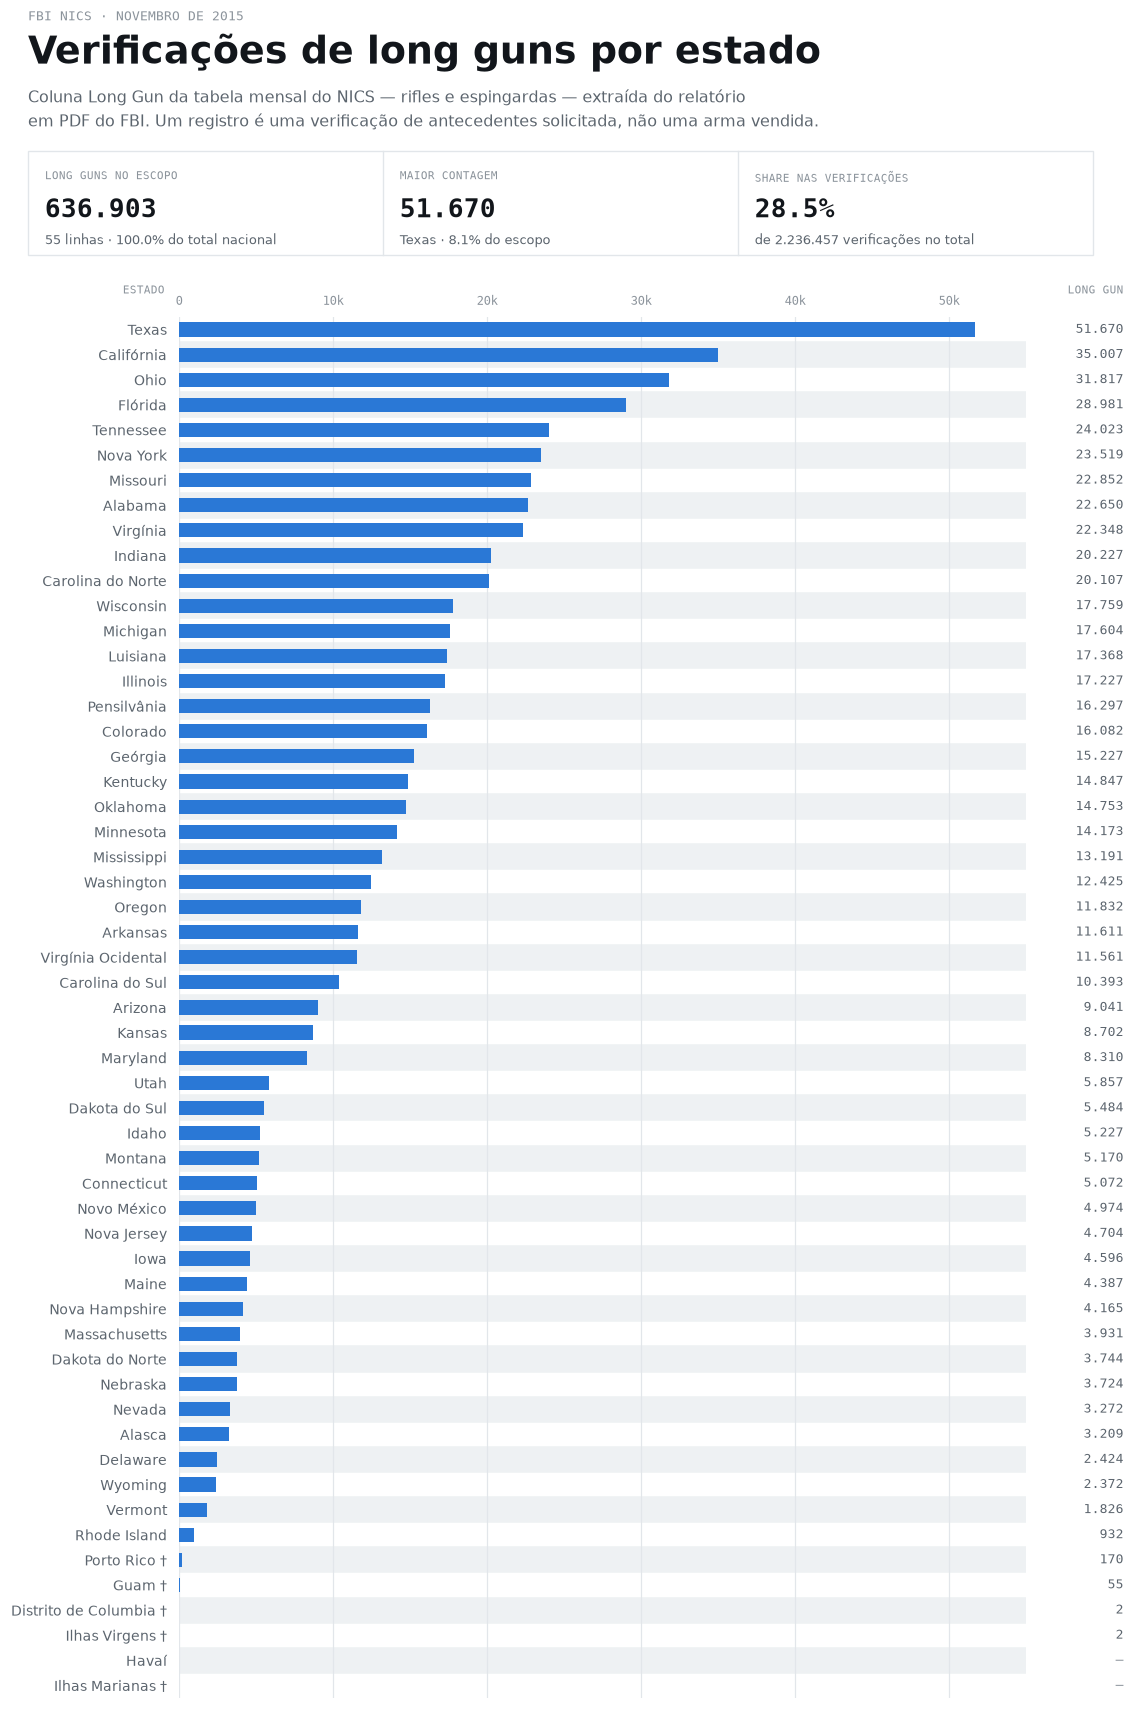

In [8]:
TINTA, TINTA_2, TINTA_3 = "#12161b", "#5c656e", "#8b939b"
FIO, FIO_2, SERIE = "#e2e6ea", "#eef1f3", "#2a78d6"
DOMINIO, PASSO = 55_000, 10_000
MONO = ["DejaVu Sans Mono"]

n = len(g)
soma = int(g["Long Gun"].sum())
checks = int(g["Totals"].sum())
topo = g.iloc[0]

fig = plt.figure(figsize=(11, 16.2), dpi=110, facecolor="white")
ax = fig.add_axes([0.185, 0.035, 0.70, 0.775])
ax.set_facecolor("white")

# ---------- cabeçalho ----------
fig.text(0.06, 0.982, "FBI NICS · NOVEMBRO DE 2015", color=TINTA_3, fontsize=8.5,
         family=MONO, va="top")
fig.text(0.06, 0.969, "Verificações de long guns por estado", color=TINTA, fontsize=25,
         fontweight="semibold", va="top")
fig.text(0.06, 0.940,
         "Coluna Long Gun da tabela mensal do NICS — rifles e espingardas — extraída do relatório\n"
         "em PDF do FBI. Um registro é uma verificação de antecedentes solicitada, não uma arma vendida.",
         color=TINTA_2, fontsize=10.5, va="top", linespacing=1.5)

# ---------- faixa de indicadores ----------
cartoes = [
    ("LONG GUNS NO ESCOPO", br(soma), f"{n} linhas · {soma / NAT_LONG * 100:.1f}% do total nacional"),
    ("MAIOR CONTAGEM", br(int(topo['Long Gun'])),
     f"{topo['estado']} · {topo['Long Gun'] / soma * 100:.1f}% do escopo"),
    ("SHARE NAS VERIFICAÇÕES", f"{soma / checks * 100:.1f}%", f"de {br(checks)} verificações no total"),
]
y0, altura, x0, larg = 0.845, 0.058, 0.06, 0.88
fig.patches.append(plt.Rectangle((x0, y0), larg, altura, transform=fig.transFigure,
                                 facecolor="white", edgecolor=FIO, linewidth=0.9, zorder=1))
for i, (rotulo, valor, nota) in enumerate(cartoes):
    x = x0 + i * larg / 3
    if i:
        fig.add_artist(plt.Line2D([x, x], [y0, y0 + altura], transform=fig.transFigure,
                                  color=FIO, linewidth=0.9))
    fig.text(x + 0.014, y0 + altura - 0.011, rotulo, color=TINTA_3, fontsize=7.2, family=MONO, va="top")
    fig.text(x + 0.014, y0 + altura - 0.026, valor, color=TINTA, fontsize=17,
             family=MONO, fontweight="semibold", va="top")
    fig.text(x + 0.014, y0 + altura - 0.046, nota, color=TINTA_2, fontsize=8.2, va="top")

# ---------- barras ----------
y = range(n)
ax.barh(y, g["Long Gun"], height=0.565, color=SERIE, zorder=3)
ax.set_ylim(n - 0.5, -0.5)
ax.set_xlim(0, DOMINIO)
ax.set_yticks(list(y), g["estado"])
ax.tick_params(axis="y", length=0, pad=8, labelsize=9.2, colors=TINTA_2)
ax.tick_params(axis="x", length=0, pad=6, labelsize=8, colors=TINTA_3, top=True,
               labeltop=True, bottom=False, labelbottom=False)
ax.set_xticks(range(0, DOMINIO - PASSO // 2 + 1, PASSO))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: "0" if v == 0 else f"{v / 1000:.0f}k"))
for rotulo in ax.get_xticklabels():
    rotulo.set_family(MONO)
ax.grid(axis="x", color=FIO, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for lado in ax.spines.values():
    lado.set_visible(False)

# faixas alternadas, para o olho não perder a linha
for i in y:
    if i % 2:
        ax.axhspan(i - 0.5, i + 0.5, color=FIO_2, zorder=0)

# valor de cada estado, à direita do eixo
mistura = blended_transform_factory(ax.transAxes, ax.transData)
for i, v in enumerate(g["Long Gun"]):
    ax.text(1.115, i, br(int(v)) if v else "—", transform=mistura, ha="right", va="center",
            fontsize=8.6, family=MONO, color=TINTA_2 if v else TINTA_3)

# títulos das colunas do painel
ax.text(-0.017, 1.017, "ESTADO", transform=ax.transAxes, ha="right", fontsize=7.2,
        family=MONO, color=TINTA_3)
ax.text(1.115, 1.017, "LONG GUN", transform=ax.transAxes, ha="right", fontsize=7.2,
        family=MONO, color=TINTA_3)

plt.show()

**Fonte:** *NICS Firearm Background Checks*, novembro de 2015 — `background-checks.pdf`, 1 página,
55 linhas (50 estados + Distrito de Columbia + 4 territórios).

**Conferência:** a soma das 55 linhas da coluna `Long Gun` dá **636.903**, idêntica ao total impresso
no PDF; as 24 colunas e as 55 linhas fecham com seus respectivos totais (célula da etapa 4).

**Ressalva do FBI:** os números representam verificações iniciadas no NICS, não armas vendidas — não há
correspondência de um para um entre verificação e venda. Havaí e Ilhas Marianas aparecem com zero, e
alguns estados têm contagem baixa porque a checagem é feita via *permit* estadual (Kentucky, por exemplo,
soma 264.140 permits).

† Distrito de Columbia e territórios (Guam, Porto Rico, Ilhas Virgens, Ilhas Marianas) — não são estados.

## 7. Salvar as saídas

O CSV com as 24 colunas extraídas e o gráfico em PNG.

In [9]:
df.to_csv("nics_nov2015_extraido.csv", index=False)
fig.savefig("grafico-long-guns.png", dpi=160, facecolor="white", bbox_inches="tight")

conferido = pd.read_csv("nics_nov2015_extraido.csv")
print("nics_nov2015_extraido.csv ->", conferido.shape)
print("grafico-long-guns.png     -> salvo")
pdf.close()

nics_nov2015_extraido.csv -> (56, 25)
grafico-long-guns.png     -> salvo
